# WBGT Learning Module 5
## Country-selected multi-model labor-capacity-loss inputs for downstream GTAP aggregation

This notebook analyzes **one selected country at a time** using the country products
generated from the bias-corrected CMIP6 workflow. Choose either `"Nigeria"` or
`"Rwanda"` in Section 1, then run the notebook from top to bottom.

It is deliberately separate from Notebook 4:

- **Notebook 4** demonstrates the full WBGT → ISO labor-capacity calculation.
- **Notebook 5** loads the selected country's member-level gridded losses, validates
  them, summarizes ensemble uncertainty, and exports compact hand-off products.

The files used here contain the grid-cell quantity

\[
z^{i,c}_{r,g}
=
\frac{\bar C^{\,c}_{\mathrm{base}}(i)-\bar C^{\,c}_{\mathrm{future}}(i)}
     {\bar C^{\,c}_{\mathrm{base}}(i)},
\]

calculated separately for each climate-model member before ensemble averaging.
They are **not yet sector- or labor-type-specific GTAP shocks**. Saeed Equation 4
still requires indoor/outdoor shares, work-intensity shares, and spatial economic
weights.

## 1. Configuration

Set `SELECTED_COUNTRY` to either `"Nigeria"` or `"Rwanda"`.

Use INPUT_STATUS = "provisional" to test. Once successful change only this setting to "final" and rerun the notebook.

The default paths point to the shared Negishi scratch directory. To run from a different location, edit INPUT_DIR and OUTPUT_DIR..

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display

INPUT_DIR = Path(
    "pth/to/input/"
)
OUTPUT_DIR = Path(
    "/pth/to/output/"
)

# Choose exactly one country.
SELECTED_COUNTRY = "Rwanda"   # "Rwanda" or "Nigeria"

INPUT_STATUS = "provisional"  # later change to "final"
WARMING_LEVEL_C = 3

CONDITIONS = ("outdoor", "indoor")
METABOLIC_RATES_W = (200, 300, 400, 600)

# The input files are currently rectangular bounding boxes.
# Keep this False unless regionmask and its Natural Earth country data
# are available in the runtime environment.
APPLY_NATIONAL_MASK = True

# Diagnostics may use either equal-member weighting or equal-source-model
# weighting. The stored *_ensemble_mean fields use equal-member weighting.
ENSEMBLE_WEIGHTING = "member"  # "member" or "source_model"

VALID_COUNTRIES = {"Nigeria", "Rwanda"}

if SELECTED_COUNTRY not in VALID_COUNTRIES:
    raise ValueError(
        "SELECTED_COUNTRY must be either 'Nigeria' or 'Rwanda'."
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

country_path = (
    INPUT_DIR
    / (
        f"gtap_input_{SELECTED_COUNTRY.lower()}_"
        f"{WARMING_LEVEL_C}C_{INPUT_STATUS}.nc"
    )
)

print("Selected country:", SELECTED_COUNTRY)
print("Input file:", country_path)

Selected country: Rwanda
Input file: /scratch/negishi/frank40/gtap_shock_inputs/combined/gtap_input_rwanda_3C_provisional.nc


## 2. Load the selected country file

Only the file corresponding to `SELECTED_COUNTRY` is opened. Changing the country
choice in Section 1 and rerunning the notebook switches the complete analysis.

In [2]:
if not country_path.exists():
    raise FileNotFoundError(
        f"Selected country file was not found: {country_path}"
    )

selected_ds = xr.open_dataset(country_path)

# Keep the one-country dictionary structure so all later analysis cells
# operate on the selected country only.
country_results = {
    SELECTED_COUNTRY: selected_ds
}

print(
    f"{SELECTED_COUNTRY}: {country_path.name}\n"
    f"  members={selected_ds.sizes.get('member', 0)}; "
    f"grid={selected_ds.sizes.get('lat', 0)} × "
    f"{selected_ds.sizes.get('lon', 0)}; "
    f"status={selected_ds.attrs.get('ensemble_status', 'unknown')}"
)

Rwanda: gtap_input_rwanda_3C_provisional.nc
  members=3; grid=13 × 15; status=provisional


## 3. Validate structure, metadata, and numerical ranges

The checks below verify:

- all eight indoor/outdoor × work-intensity member fields are present;
- stored ensemble means equal the mean of the member fields;
- losses are finite and lie in the expected fractional range;
- the selected-country and climate-sample metadata are explicit.

In [3]:
BASE_VARIABLES = {
    f"capacity_loss_{condition}_{rate}W"
    for condition in CONDITIONS
    for rate in METABOLIC_RATES_W
}


def validate_country_dataset(ds, country):
    problems = []

    missing = sorted(BASE_VARIABLES - set(ds.data_vars))
    if missing:
        problems.append(f"missing member-level variables: {missing}")

    for name in sorted(BASE_VARIABLES & set(ds.data_vars)):
        da = ds[name]

        expected_dims = {"member", "lat", "lon"}
        if set(da.dims) != expected_dims:
            problems.append(
                f"{name}: dimensions {da.dims}, expected member/lat/lon"
            )

        if bool(da.isnull().any()):
            problems.append(f"{name}: contains missing values")

        minimum = float(da.min())
        maximum = float(da.max())

        if minimum < -1.0e-6:
            problems.append(f"{name}: minimum below zero ({minimum:.6g})")
        if maximum > 1.0 + 1.0e-6:
            problems.append(f"{name}: maximum above one ({maximum:.6g})")

        mean_name = f"{name}_ensemble_mean"
        if mean_name not in ds:
            problems.append(f"{mean_name}: missing")
        else:
            recomputed = da.mean("member")
            difference = float(
                abs(recomputed - ds[mean_name]).max()
            )
            if difference > 1.0e-6:
                problems.append(
                    f"{mean_name}: differs from member mean by {difference:.3g}"
                )

    declared_country = str(ds.attrs.get("country", ""))
    if declared_country.casefold() != country.casefold():
        problems.append(
            f"country metadata is {declared_country!r}, expected {country!r}"
        )

    number_of_years = int(ds.attrs.get("number_of_era5_years", -1))
    if number_of_years <= 0:
        problems.append("number_of_era5_years is missing or invalid")

    if "member" not in ds.dims or ds.sizes["member"] == 0:
        problems.append("member dimension is missing or empty")

    if problems:
        print(f"{country}: CHECK")
        for problem in problems:
            print("  -", problem)
    else:
        print(f"{country}: validation passed")

    return problems


validation_problems = {
    country: validate_country_dataset(ds, country)
    for country, ds in country_results.items()
}


validation_problems = validate_country_dataset(
    selected_ds,
    SELECTED_COUNTRY,
)

if validation_problems:
    raise ValueError(
        "The selected country file failed validation. "
        "Review the messages printed above."
    )


Rwanda: validation passed
Rwanda: validation passed


## 4. Inspect provenance and ensemble membership

The current products use a 26-year sample because ERA5 year 1967 is unavailable.
A provisional file may contain fewer than the final 18 member series.

In [4]:
metadata_table = pd.DataFrame([{
    "Country": SELECTED_COUNTRY,
    "Status": selected_ds.attrs.get("ensemble_status"),
    "Members": selected_ds.sizes.get("member"),
    "ERA5 years": selected_ds.attrs.get("number_of_era5_years"),
    "Missing ERA5 years": selected_ds.attrs.get("missing_era5_years"),
    "Country selection": selected_ds.attrs.get("country_selection"),
    "Warming level (°C)": selected_ds.attrs.get("warming_level_C"),
}])

display(metadata_table)

print(f"\n{SELECTED_COUNTRY} members:")
for member in selected_ds.member.values.astype(str):
    print(" ", member)

,Country,Status,Members,ERA5 years,Missing ERA5 years,Country selection,Warming level (°C)
0,Rwanda,provisional,3,26,1967,Rectangular country bounding box; exact nation...,3



Rwanda members:
  ACCESS-CM2
  BCC-CSM2-MR
  CMCC-CM2-SR5


## 5. Optional national-boundary mask

The selected file currently covers a country bounding box. This is useful for storage
and mapping but may include neighboring land and, for Nigeria, some water. When
`APPLY_NATIONAL_MASK=True`, this section masks grid-cell centers outside the selected
country boundary using `regionmask`.

The default remains `False` because Natural Earth country data may not be installed
on every compute node. Downstream GTAP aggregation should ultimately use exact
country cells and population/agricultural-production weights rather than a simple
bounding-box average.

In [5]:
analysis_results = {
    country: ds.copy()
    for country, ds in country_results.items()
}

if APPLY_NATIONAL_MASK:
    import regionmask

    countries_region = None
    for version in (
        "natural_earth_v5_1_2",
        "natural_earth_v5_0_0",
        "natural_earth_v4_1_0",
    ):
        if hasattr(regionmask.defined_regions, version):
            countries_region = (
                getattr(regionmask.defined_regions, version)
                .countries_110
            )
            break

    if countries_region is None:
        raise RuntimeError(
            "No compatible Natural Earth country collection was found."
        )

    for country, ds in analysis_results.items():
        number = next(
            number
            for number, name in zip(
                countries_region.numbers,
                countries_region.names,
            )
            if name.casefold() == country.casefold()
        )

        inside = (
            countries_region.mask(
                ds["lon"],
                ds["lat"],
                wrap_lon=False,
            )
            == number
        )

        analysis_results[country] = ds.where(inside)
        print(
            f"{country}: retained {int(inside.sum())} "
            "grid-cell centers inside the national boundary."
        )
else:
    print(
        "APPLY_NATIONAL_MASK is False: diagnostics use the stored "
        "rectangular country boxes."
    )

APPLY_NATIONAL_MASK is False: diagnostics use the stored rectangular country boxes.


## 6. Ensemble weighting

The production files store an **equal-member** ensemble mean. Some source models
have more than one realization in the archive, so this notebook also supports an
**equal-source-model** diagnostic:

1. average realizations belonging to the same source model;
2. give each source model equal weight.

This alternative affects only the analysis below; it does not alter the input files.

In [6]:
REALIZATION_SUFFIX = re.compile(
    r"_r\d+i\d+p\d+f\d+$"
)


def source_model_names(member_values):
    return np.array([
        REALIZATION_SUFFIX.sub("", str(member))
        for member in member_values
    ])


def ensemble_field(ds, base_variable, weighting="member"):
    da = ds[base_variable]

    if weighting == "member":
        return da.mean("member", skipna=True)

    if weighting == "source_model":
        labels = source_model_names(
            ds.member.values.astype(str)
        )

        grouped = (
            da.assign_coords(
                source_model=("member", labels)
            )
            .groupby("source_model")
            .mean("member", skipna=True)
        )

        return grouped.mean(
            "source_model",
            skipna=True,
        )

    raise ValueError(
        "weighting must be 'member' or 'source_model'"
    )


for country, ds in analysis_results.items():
    labels = source_model_names(ds.member.values.astype(str))
    print(
        f"{country}: {ds.sizes['member']} member series "
        f"from {len(np.unique(labels))} source models"
    )

Rwanda: 3 member series from 3 source models


## 7. Area-weighted diagnostic summary

These are **diagnostic spatial averages**, not the final Saeed Equation 4
aggregation. Grid cells are weighted by cosine of latitude to approximate cell area.
The final GTAP workflow instead needs population weights for nonagricultural work
and agricultural-production weights for agricultural work.

In [7]:
def area_weighted_mean(da):
    weights = np.cos(
        np.deg2rad(da["lat"])
    )
    return da.weighted(weights).mean(
        ("lat", "lon"),
        skipna=True,
    )


summary_rows = []

for country, ds in analysis_results.items():
    for condition in CONDITIONS:
        for rate in METABOLIC_RATES_W:
            base_name = (
                f"capacity_loss_{condition}_{rate}W"
            )

            field = ensemble_field(
                ds,
                base_name,
                weighting=ENSEMBLE_WEIGHTING,
            )

            member_country_means = area_weighted_mean(
                ds[base_name]
            )

            summary_rows.append({
                "Country": country,
                "Condition": condition,
                "Metabolic rate (W)": rate,
                "Area-weighted ensemble loss (%)": (
                    100.0 * float(area_weighted_mean(field))
                ),
                "Lowest member mean (%)": (
                    100.0 * float(member_country_means.min())
                ),
                "Highest member mean (%)": (
                    100.0 * float(member_country_means.max())
                ),
                "Members": ds.sizes["member"],
                "Weighting": ENSEMBLE_WEIGHTING,
            })

summary_table = pd.DataFrame(summary_rows)

display(
    summary_table.round(3).sort_values(
        ["Country", "Condition", "Metabolic rate (W)"]
    )
)

,Country,Condition,Metabolic rate (W),Area-weighted ensemble loss (%),Lowest member mean (%),Highest member mean (%),Members,Weighting
4,Rwanda,indoor,200,0.000,0.000,0.000,3,member
5,Rwanda,indoor,300,0.002,0.001,0.003,3,member
6,Rwanda,indoor,400,0.042,0.030,0.053,3,member
7,Rwanda,indoor,600,0.566,0.479,0.687,3,member
0,Rwanda,outdoor,200,0.326,0.294,0.385,3,member
1,Rwanda,outdoor,300,1.124,0.984,1.336,3,member
2,Rwanda,outdoor,400,2.454,2.132,2.905,3,member
3,Rwanda,outdoor,600,6.041,5.311,6.986,3,member


## 8. Work-intensity response

The expected pattern is a larger capacity loss at higher metabolic rates. The plot
uses the same ensemble weighting selected above and displays area-weighted
bounding-box or masked-country diagnostics.

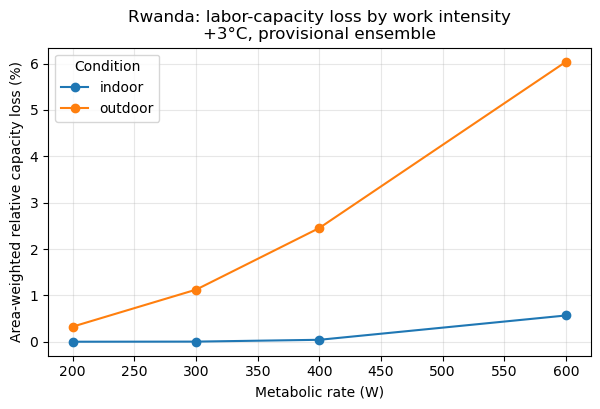

In [8]:
for country in analysis_results:
    country_table = (
        summary_table[
            summary_table["Country"] == country
        ]
        .pivot(
            index="Metabolic rate (W)",
            columns="Condition",
            values="Area-weighted ensemble loss (%)",
        )
        .sort_index()
    )

    ax = country_table.plot(
        marker="o",
        figsize=(7, 4),
    )
    ax.set_title(
        f"{country}: labor-capacity loss by work intensity\n"
        f"+{WARMING_LEVEL_C}°C, {INPUT_STATUS} ensemble"
    )
    ax.set_ylabel("Area-weighted relative capacity loss (%)")
    ax.set_xlabel("Metabolic rate (W)")
    ax.grid(True, alpha=0.3)
    plt.show()

## 9. Spatial map

The map displays the selected condition and work intensity for the chosen country.
Areas outside the national boundary appear blank when masking is enabled.

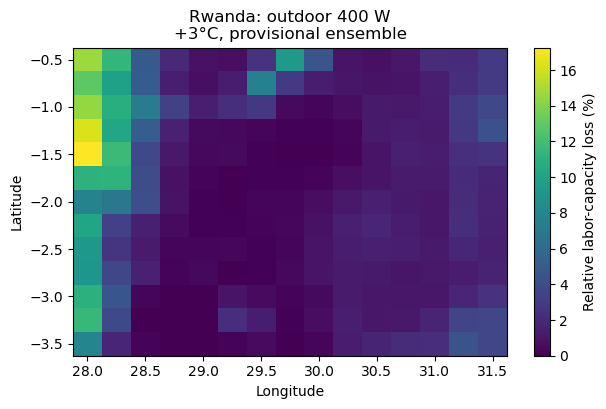

In [9]:
MAP_CONDITION = "outdoor"
MAP_RATE_W = 400

map_variable = (
    f"capacity_loss_{MAP_CONDITION}_{MAP_RATE_W}W"
)

field = (
    100.0
    * ensemble_field(
        analysis_results[SELECTED_COUNTRY],
        map_variable,
        weighting=ENSEMBLE_WEIGHTING,
    )
)

plt.figure(figsize=(7, 4))

field.plot(
    x="lon",
    y="lat",
    vmin=0.0,
    vmax=float(field.max(skipna=True)),
    cbar_kwargs={
        "label": "Relative labor-capacity loss (%)"
    },
)

plt.title(
    f"{SELECTED_COUNTRY}: {MAP_CONDITION} {MAP_RATE_W} W\n"
    f"+{WARMING_LEVEL_C}°C, {INPUT_STATUS} ensemble"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
import regionmask

map_variable = (
    f"capacity_loss_{MAP_CONDITION}_"
    f"{MAP_RATE_W}W"
)

# Full field used for drawing. The polygon clip fills Rwanda
# continuously rather than retaining only cell centers.
display_field = (
    100.0
    * ensemble_field(
        country_results[SELECTED_COUNTRY],
        map_variable,
        weighting=ENSEMBLE_WEIGHTING,
    )
)

country_boundary = get_country_geometry(
    SELECTED_COUNTRY
)

country_geometry = country_boundary.iloc[0]

# Construct a mask from the same high-resolution polygon.
scale_regions = regionmask.Regions(
    outlines=[country_geometry],
    names=[SELECTED_COUNTRY],
    abbrevs=[SELECTED_COUNTRY[:3]],
    numbers=[0],
)

inside_for_scale = (
    scale_regions.mask(
        display_field["lon"],
        display_field["lat"],
        wrap_lon=False,
    )
    == 0
)

# This field is used only to establish the colour scale.
scale_field = display_field.where(
    inside_for_scale
)

colour_minimum = 0.0
colour_maximum = float(
    scale_field.max(skipna=True)
)

print(
    "Maximum over full bounding box:",
    float(display_field.max(skipna=True)),
)

print(
    "Maximum using Rwanda grid-cell centres:",
    colour_maximum,
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import regionmask

from matplotlib.path import Path as MatplotlibPath
from matplotlib.patches import PathPatch


# ============================================================
# Map settings
# ============================================================

MAP_CONDITION = "outdoor"
MAP_RATE_W = 400


# Key cities to plot. Edit freely.
KEY_CITIES = {
    "Rwanda": {
        "Kigali": (-1.9441, 30.0619),
        "Huye": (-2.5967, 29.7394),
        "Musanze": (-1.4996, 29.6344),
        "Rubavu": (-1.67638, 29.26871),
    },
    "Nigeria": {
        "Abuja": (9.0765, 7.3986),
        "Lagos": (6.5244, 3.3792),
        "Kano": (12.0022, 8.5920),
        "Port Harcourt": (4.8156, 7.0498),
        "Ibadan": (7.3775, 3.9470),
        "Maiduguri": (11.8333, 13.1500),
    },
}

SHOW_COUNTRY_BOUNDARY = True
SHOW_KEY_CITIES = True


# ============================================================
# Convert Shapely geometry to a Matplotlib clipping path
# ============================================================

def shapely_to_matplotlib_path(geometry):
    """
    Convert a Shapely Polygon or MultiPolygon into a
    Matplotlib Path suitable for clipping a raster.
    """

    vertices = []
    codes = []

    def add_ring(ring):
        coordinates = np.asarray(
            ring.coords,
            dtype=float,
        )

        number_of_points = len(
            coordinates
        )

        vertices.extend(
            coordinates
        )

        codes.extend(
            [MatplotlibPath.MOVETO]
            + [MatplotlibPath.LINETO]
            * (number_of_points - 2)
            + [MatplotlibPath.CLOSEPOLY]
        )

    if geometry.geom_type == "Polygon":
        polygons = [geometry]

    elif geometry.geom_type == "MultiPolygon":
        polygons = list(
            geometry.geoms
        )

    else:
        raise TypeError(
            "Unsupported geometry type: "
            f"{geometry.geom_type}"
        )

    for polygon in polygons:
        add_ring(
            polygon.exterior
        )

        for interior in polygon.interiors:
            add_ring(
                interior
            )

    return MatplotlibPath(
        np.asarray(vertices),
        np.asarray(codes),
    )


# ============================================================
# Prepare the full field
# ============================================================

map_variable = (
    f"capacity_loss_{MAP_CONDITION}_"
    f"{MAP_RATE_W}W"
)

# Use the original bounding-box dataset for display.
# Do not use analysis_results here because it may already
# contain a grid-cell-centre national mask.
display_ds = country_results[
    SELECTED_COUNTRY
]

display_field = (
    100.0
    * ensemble_field(
        display_ds,
        map_variable,
        weighting=ENSEMBLE_WEIGHTING,
    )
)


# ============================================================
# Obtain the national polygon
# ============================================================

country_boundary = get_country_geometry(
    SELECTED_COUNTRY
)

country_geometry = (
    country_boundary.iloc[0]
)


# ============================================================
# Determine colour limits using only in-country cell centres
# ============================================================

scale_region = regionmask.Regions(
    outlines=[
        country_geometry
    ],
    names=[
        SELECTED_COUNTRY
    ],
    abbrevs=[
        SELECTED_COUNTRY[:3]
    ],
    numbers=[
        0
    ],
)

inside_country_centres = (
    scale_region.mask(
        display_field["lon"],
        display_field["lat"],
        wrap_lon=False,
    )
    == 0
)

scale_field = display_field.where(
    inside_country_centres
)

colour_minimum = 0.0

colour_maximum = float(
    scale_field.max(
        skipna=True
    )
)

if (
    not np.isfinite(colour_maximum)
    or colour_maximum <= colour_minimum
):
    raise ValueError(
        "Could not calculate a valid in-country colour scale."
    )

print(
    "Full bounding-box maximum:",
    float(
        display_field.max(
            skipna=True
        )
    ),
)

print(
    "In-country colour-scale maximum:",
    colour_maximum,
)


# ============================================================
# Draw and clip the raster
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.5, 5.5)
)

raster = display_field.plot(
    ax=ax,
    x="lon",
    y="lat",
    vmin=colour_minimum,
    vmax=colour_maximum,
    cbar_kwargs={
        "label": (
            "Relative labor-capacity loss (%)"
        )
    },
)

clip_path = shapely_to_matplotlib_path(
    country_geometry
)

clip_patch = PathPatch(
    clip_path,
    transform=ax.transData,
    facecolor="none",
    edgecolor="none",
)

ax.add_patch(
    clip_patch
)

raster.set_clip_path(
    clip_patch
)


# ============================================================
# Draw national boundary
# ============================================================

if SHOW_COUNTRY_BOUNDARY:
    country_boundary.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.5,
        zorder=5,
    )


# ============================================================
# Add key cities
# ============================================================

if (
    SHOW_KEY_CITIES
    and SELECTED_COUNTRY in KEY_CITIES
):
    for city, (
        latitude,
        longitude,
    ) in KEY_CITIES[
        SELECTED_COUNTRY
    ].items():

        ax.scatter(
            longitude,
            latitude,
            s=34,
            color="black",
            zorder=7,
        )

        ax.annotate(
            city,
            xy=(
                longitude,
                latitude,
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="bottom",
            bbox={
                "facecolor": "white",
                "alpha": 0.75,
                "edgecolor": "none",
                "pad": 1.5,
            },
            zorder=8,
        )


# ============================================================
# Set geographic extent
# ============================================================

minimum_x, minimum_y, maximum_x, maximum_y = (
    country_boundary.total_bounds
)

padding_x = max(
    0.15,
    0.06
    * (
        maximum_x
        - minimum_x
    ),
)

padding_y = max(
    0.15,
    0.06
    * (
        maximum_y
        - minimum_y
    ),
)

ax.set_xlim(
    minimum_x - padding_x,
    maximum_x + padding_x,
)

ax.set_ylim(
    minimum_y - padding_y,
    maximum_y + padding_y,
)


# ============================================================
# Labels
# ============================================================

ax.set_title(
    f"{SELECTED_COUNTRY}: "
    f"{MAP_CONDITION} {MAP_RATE_W} W\n"
    f"+{WARMING_LEVEL_C}°C, "
    f"{INPUT_STATUS} ensemble"
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

plt.show()

## 10. Member uncertainty

This diagnostic compares each member's area-weighted country mean. It helps reveal
whether the ensemble mean is representative or dominated by a small number of hot
members.

,Country,Member,Loss (%)
1,Rwanda,BCC-CSM2-MR,2.132
2,Rwanda,CMCC-CM2-SR5,2.326
0,Rwanda,ACCESS-CM2,2.905


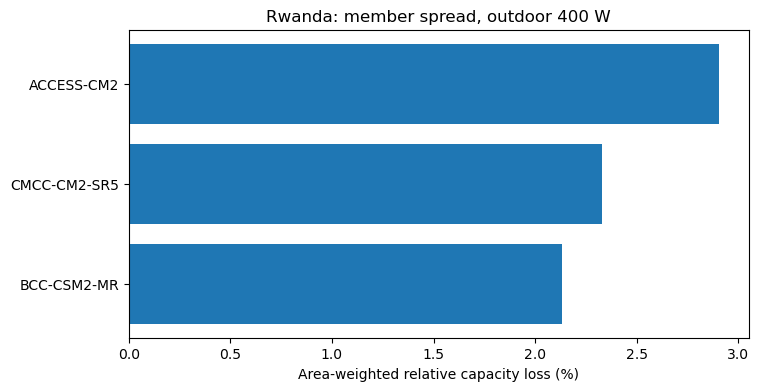

In [10]:
UNCERTAINTY_CONDITION = "outdoor"
UNCERTAINTY_RATE_W = 400

uncertainty_variable = (
    f"capacity_loss_{UNCERTAINTY_CONDITION}_"
    f"{UNCERTAINTY_RATE_W}W"
)

uncertainty_rows = []

for country, ds in analysis_results.items():
    member_means = (
        100.0
        * area_weighted_mean(
            ds[uncertainty_variable]
        )
    )

    for member, value in zip(
        ds.member.values.astype(str),
        member_means.values,
    ):
        uncertainty_rows.append({
            "Country": country,
            "Member": member,
            "Loss (%)": float(value),
        })

uncertainty_table = pd.DataFrame(
    uncertainty_rows
)

display(
    uncertainty_table.sort_values(
        ["Country", "Loss (%)"]
    ).round(3)
)

for country in uncertainty_table["Country"].unique():
    plot_data = (
        uncertainty_table[
            uncertainty_table["Country"] == country
        ]
        .sort_values("Loss (%)")
    )

    plt.figure(
        figsize=(
            8,
            max(4, 0.32 * len(plot_data)),
        )
    )
    plt.barh(
        plot_data["Member"],
        plot_data["Loss (%)"],
    )
    plt.xlabel("Area-weighted relative capacity loss (%)")
    plt.title(
        f"{country}: member spread, "
        f"{UNCERTAINTY_CONDITION} {UNCERTAINTY_RATE_W} W"
    )
    plt.show()

## 11. Equal-member versus equal-source-model sensitivity

This comparison is most relevant when multiple realizations exist for the same
source model. Large differences would indicate that the choice of ensemble
weighting should be documented explicitly in the final hand-off.

In [11]:
weighting_rows = []

for country, ds in analysis_results.items():
    for condition in CONDITIONS:
        for rate in METABOLIC_RATES_W:
            base_name = (
                f"capacity_loss_{condition}_{rate}W"
            )

            member_mean = area_weighted_mean(
                ensemble_field(
                    ds,
                    base_name,
                    weighting="member",
                )
            )

            source_model_mean = area_weighted_mean(
                ensemble_field(
                    ds,
                    base_name,
                    weighting="source_model",
                )
            )

            weighting_rows.append({
                "Country": country,
                "Condition": condition,
                "Metabolic rate (W)": rate,
                "Equal-member loss (%)": (
                    100.0 * float(member_mean)
                ),
                "Equal-source-model loss (%)": (
                    100.0 * float(source_model_mean)
                ),
                "Difference (percentage points)": (
                    100.0
                    * float(source_model_mean - member_mean)
                ),
            })

weighting_table = pd.DataFrame(weighting_rows)
display(weighting_table.round(4))

,Country,Condition,Metabolic rate (W),Equal-member loss (%),Equal-source-model loss (%),Difference (percentage points)
0,Rwanda,outdoor,200,0.3262,0.3262,0.0
1,Rwanda,outdoor,300,1.1236,1.1236,0.0
2,Rwanda,outdoor,400,2.4545,2.4545,0.0
3,Rwanda,outdoor,600,6.0408,6.0408,0.0
4,Rwanda,indoor,200,0.0000,0.0000,0.0
5,Rwanda,indoor,300,0.0025,0.0025,0.0
6,Rwanda,indoor,400,0.0416,0.0416,0.0
7,Rwanda,indoor,600,0.5664,0.5664,0.0


## 12. Sign convention for downstream GTAP work

The stored fields are positive fractional **losses**. For example, `0.08` means an
8% loss of labor capacity.

A model input expressed as a percentage change in labor-augmenting productivity
would normally use the opposite sign:

\[
\text{productivity shock (\%)} = -100\,z.
\]

This sign conversion alone does **not** complete Saeed Equation 4. The gridded
condition- and intensity-specific losses must first be combined using labor/activity
shares and appropriate spatial economic weights.

In [12]:
EXAMPLE_CONDITION = "outdoor"
EXAMPLE_RATE_W = 400

example_name = (
    f"capacity_loss_{EXAMPLE_CONDITION}_"
    f"{EXAMPLE_RATE_W}W"
)

gtap_sign_examples = {}

for country, ds in analysis_results.items():
    loss_fraction = ensemble_field(
        ds,
        example_name,
        weighting=ENSEMBLE_WEIGHTING,
    )

    gtap_sign_examples[country] = (
        -100.0 * loss_fraction
    )

    print(
        f"{country}: diagnostic productivity-shock range "
        f"for {EXAMPLE_CONDITION} {EXAMPLE_RATE_W} W = "
        f"{float(gtap_sign_examples[country].min()):.2f}% to "
        f"{float(gtap_sign_examples[country].max()):.2f}%"
    )

Rwanda: diagnostic productivity-shock range for outdoor 400 W = -17.25% to -0.00%


## 13. Export compact analysis products

The export contains, for every condition and work intensity:

- the selected ensemble-mean field;
- equal-member and equal-source-model means;
- member minimum and maximum fields.

It remains a gridded pre-Equation-4 hand-off, not a sectoral GTAP shock.
A CSV containing the diagnostic country summaries is also written.

In [ ]:
export_paths = []

for country, ds in analysis_results.items():
    compact = xr.Dataset()

    for condition in CONDITIONS:
        for rate in METABOLIC_RATES_W:
            base_name = (
                f"capacity_loss_{condition}_{rate}W"
            )

            compact[
                f"{base_name}_selected_mean"
            ] = ensemble_field(
                ds,
                base_name,
                weighting=ENSEMBLE_WEIGHTING,
            ).astype("float32")

            compact[
                f"{base_name}_equal_member_mean"
            ] = ensemble_field(
                ds,
                base_name,
                weighting="member",
            ).astype("float32")

            compact[
                f"{base_name}_equal_source_model_mean"
            ] = ensemble_field(
                ds,
                base_name,
                weighting="source_model",
            ).astype("float32")

            compact[
                f"{base_name}_member_min"
            ] = ds[base_name].min(
                "member",
                skipna=True,
            ).astype("float32")

            compact[
                f"{base_name}_member_max"
            ] = ds[base_name].max(
                "member",
                skipna=True,
            ).astype("float32")

    compact.attrs.update({
        "country": country,
        "warming_level_C": WARMING_LEVEL_C,
        "input_status": INPUT_STATUS,
        "selected_ensemble_weighting": ENSEMBLE_WEIGHTING,
        "number_of_member_series": ds.sizes["member"],
        "members": ",".join(
            ds.member.values.astype(str)
        ),
        "number_of_era5_years": ds.attrs.get(
            "number_of_era5_years"
        ),
        "missing_era5_years": ds.attrs.get(
            "missing_era5_years"
        ),
        "country_selection": (
            "National-boundary mask applied in Notebook 5"
            if APPLY_NATIONAL_MASK
            else ds.attrs.get(
                "country_selection",
                "rectangular bounding box",
            )
        ),
        "product": (
            "Gridded condition- and intensity-specific "
            "labor-capacity losses for downstream Saeed Equation 4 aggregation"
        ),
        "not_final_gtap_shock": (
            "Requires work-intensity shares, indoor/outdoor shares, "
            "spatial economic weights, and GTAP labor/activity mapping"
        ),
    })

    output_path = (
        OUTPUT_DIR
        / (
            f"capacity_loss_{country.lower()}_"
            f"{WARMING_LEVEL_C}C_{INPUT_STATUS}_compact.nc"
        )
    )

    encoding = {
        variable: {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
            "shuffle": True,
        }
        for variable in compact.data_vars
    }

    compact.to_netcdf(
        output_path,
        encoding=encoding,
    )

    export_paths.append(output_path)
    print("Wrote:", output_path)

summary_csv = (
    OUTPUT_DIR
    / (
        f"country_capacity_loss_summary_"
        f"{WARMING_LEVEL_C}C_{INPUT_STATUS}.csv"
    )
)

summary_table.to_csv(
    summary_csv,
    index=False,
)

print("Wrote:", summary_csv)

## 14. Final-run checklist

When all processing jobs have finished:

1. regenerate the combined files with `--label final --require-members 18`;
2. set `SELECTED_COUNTRY` to the country being analyzed;
3. set `INPUT_STATUS = "final"` in Section 1;
4. confirm the selected country reports 18 member series;
5. rerun all cells;
6. inspect equal-member versus equal-source-model sensitivity;
7. retain the limitation that 1967 is missing unless that year is later restored;
8. use the exported grids only as inputs to the downstream sector/labor/spatial
   weighting stage.

Run the notebook once with `SELECTED_COUNTRY = "Rwanda"` and once with
`SELECTED_COUNTRY = "Nigeria"` to create separate country analyses and exports.
Notebook 4 should remain the transparent Ghana methodology demonstration.